# Personal Information
Name: Marit van den Helder

StudentID: 13970097

Email: [marit.van.den.helder@student.uva.nl](marit.van.den.helder@student.uva.nl)

Submitted on: 23.03.2026

# Data Context
NH Nieuws publishes local news from the Noord Holland province in the Netherlands. Articles range from updates on emergencies, to reports of sport matches to interviews with locals. All articles are written in Dutch, but often have automatic translations available. In some cases, a 'translation' to an easier level of Dutch is also available. 

The main dataset consists of the written articles published by NH Nieuws. The individual articles are available in a JSON format. Each article has all its metadata included, such as the author, date of publishing and type of article. The text is given in a structured format, meaning title, summary, headers and paragraphs are easily individually accessible.

The goal of the thesis is to create an improved information retrieval system for the internal content management system. The general approach will include both the integration of traditional retrieval techniques (such as an exploration of TF-IDF) and more recent LLM integrations (such as RAG).

# Data Description

The total number of articles in the dataset is ...

In [2]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

### Data Sample

In [3]:
# Data sample
with open('bruinvis.json', 'r') as file:
    data = json.load(file)

print(json.dumps(data, indent=4))

{
    "data": {
        "type": "article",
        "id": "357903",
        "attributes": {
            "workflow": 0,
            "online_date": "2026-03-11T19:00:00+00:00",
            "offline_date": null,
            "title": "Gestrande bruinvissen maken het goed en zwemmen zelfstandig bij SOS Dolfijn",
            "alternative_title": "",
            "template": "nieuws_artikel",
            "show_ads": true,
            "comments": false,
            "not_suitable_content": false,
            "push_message_sent": false,
            "slug": "gestrande-bruinvissen-maken-het-goed-en-zwemmen-zelfstandig-bij-sos-dolfijn",
            "image_id": 573571,
            "region_id": 45,
            "region_text": "Anna Paulowna",
            "sent_to_rpo": true,
            "deleted": false,
            "changed": "2026-03-11T20:37:52+00:00",
            "meta_description": "Gestrande bruinvissen op Vlieland herstellen goed bij SOS Dolfijn in Anna Paulowna: dieren zwemmen zelfstandig en ete

### Overview of quantities of the data 

In [4]:
# Retrieve all article names from the directory
folders = os.listdir('../../articles')

article_names = {}

for folder in folders:
    months = os.listdir(f'../../articles/{folder}')

    article_names[int(folder)] = {}

    for month in months:
        article_names[int(folder)][month] = set(os.listdir(f'../../articles/{folder}/{month}'))

print(article_names[2023]['01'])

{'313333.json', '312965.json', '313665.json', '314080.json', '314044.json', '313612.json', '314026.json', '313236.json', '313990.json', '313861.json', '313851.json', '313182.json', '314003.json', '313417.json', '313625.json', '313134.json', '313155.json', '313815.json', '314007.json', '313407.json', '312971.json', '313598.json', '313857.json', '313123.json', '314011.json', '313169.json', '313128.json', '313938.json', '313500.json', '313914.json', '312890.json', '313299.json', '313027.json', '313145.json', '313512.json', '313214.json', '313307.json', '313644.json', '313371.json', '313745.json', '312899.json', '313920.json', '312960.json', '313440.json', '313040.json', '313980.json', '313096.json', '313359.json', '313414.json', '314012.json', '313534.json', '313979.json', '313187.json', '313311.json', '313597.json', '313943.json', '313451.json', '313643.json', '313617.json', '313104.json', '313032.json', '312929.json', '313053.json', '313809.json', '313662.json', '313743.json', '313059.j

In [5]:
# Plot the number of articles per year
n_articles = []
for year in sorted(list(article_names.keys())):
    article_sum = 0

    for month, articles in article_names[year].items():
        article_sum += len(articles)
    
    n_articles.append(article_sum)

print(n_articles)

[80, 67, 4088, 14936, 11222, 11246, 10482, 11840, 11342, 17328, 20845, 17658, 17826, 17231, 19555, 20941, 17507, 16964, 14566, 16010, 13570, 10637, 2261]


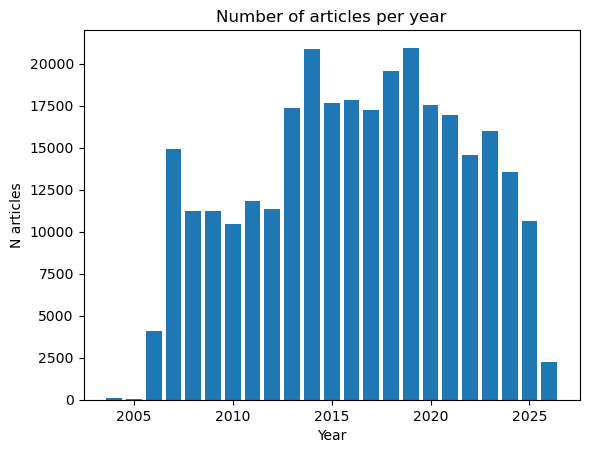

In [6]:
plt.bar(sorted(article_names.keys()), 
        height=n_articles)
plt.xlabel('Year')
plt.ylabel('N articles')
plt.title("Number of articles per year")
plt.show()

In [7]:
# Show the average file sizes as a proxy for article length to see if there is a change over time
cum_filesize = []
for year in sorted(list(article_names.keys())):
    size_sum = 0

    for month, articles in article_names[year].items():

        for article in articles:
            size_sum += os.path.getsize(f'../../articles/{year}/{month}/{article}')
    
    cum_filesize.append(size_sum)

print(cum_filesize)

[256506, 212232, 15735779, 59996884, 47717674, 50313274, 48410086, 59502798, 57808300, 89222153, 110365461, 104568251, 101412281, 100926558, 118458305, 147169931, 171684902, 187773360, 177205882, 201083097, 176198818, 145346974, 30064278]


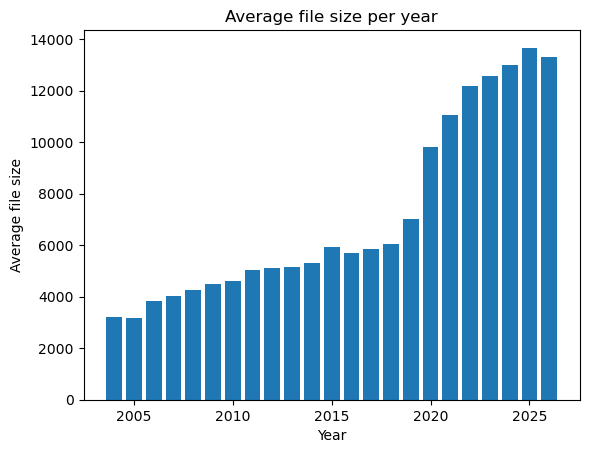

In [8]:
height = np.divide(np.array(cum_filesize), np.array(n_articles))

plt.bar(sorted(article_names.keys()), 
        height=height)
plt.xlabel('Year')
plt.ylabel('Average file size')
plt.title("Average file size per year")
plt.show()

### Insight in the file structure

In [ ]:
# Retrieve the flat text from the files

for month in os.listdir('../../articles/2004'):
    for article_name in os.listdir(f'../../articles/2004/{month}'):
        with open(f'../../articles/2004/{month}/{article_name}', mode='r', encoding='utf-8') as file:
            article = json.load(file)
            for section in article['included']:
                if section['type'] == 'block-intro':
                    pass
                if section['type'] == 'block-text':
                    pass
                print(section)
        print()

{'type': 'image-block-header', 'id': '347083', 'attributes': {'title': 'NH Nieuws logo', 'caption': '', 'alt_text': 'Logo van NH Nieuws met grote witte letters "NH" op een blauwe achtergrond, vergezeld door het woord "NIEUWS" aan de rechterkant. De achtergrond heeft een verloop van blauwe tinten met geometrische patronen.', 'author': 'NH Media', 'clearance': True, 'changed': '2025-01-29T21:50:18+00:00', 'crop': 'https://media.nhnieuws.nl/images/347083.e22b549.jpg'}}
{'type': 'block-header', 'id': '38245', 'attributes': {'deleted': False, 'changed': '2019-11-04T17:58:26+00:00'}, 'relationships': {'image': {'data': {'type': 'image-block-header', 'id': '347083'}}, 'videos': {'data': []}}}
{'type': 'block-intro', 'id': '38228', 'attributes': {'text': '<p><strong>BADHOEVEDORP De politie zoekt getuigen van een overval dinsdag rond 17.30 uur op een supermarkt op de Sloterweg in Badhoevedorp. De overvallers zijn lopend gevlucht. Niemand raakte gewond.</strong></p>', 'deleted': False, 'changed'

### Analysis n:

In [10]:
# ...